In [58]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import TypedDict, Literal
from dotenv import load_dotenv

In [59]:
load_dotenv()

True

In [60]:
model=ChatOpenAI(model='gpt-4o-mini')

In [61]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [62]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"]= Field(description='Sentiment of the review')

In [63]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone:Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
   

In [64]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [65]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [66]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [67]:
def check_sentiment(state: ReviewState) -> Literal["positive_review", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_review'
    else:
        return 'run_diagnosis'

In [68]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [69]:
def negative_review(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [70]:
def positive_review(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

In [71]:
graph=StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_review', negative_review)
graph.add_node('positive_review', positive_review)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_review', END)
graph.add_edge('run_diagnosis', 'negative_review')
graph.add_edge('negative_review', END)

workflow = graph.compile()

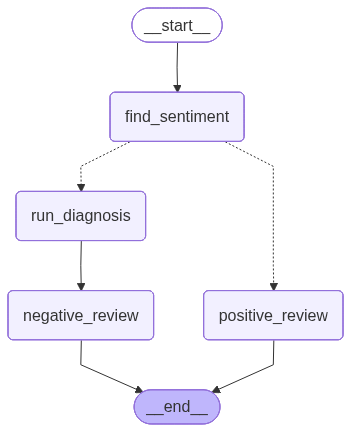

In [72]:
workflow

In [73]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Issue\n\nDear [User's Name],\n\nI hope this message finds you well. I want to sincerely apologize for the frustration you're experiencing with the bug you've encountered. I can understand how urgent this situation must feel, and I appreciate your patience as we work together to resolve it.\n\nTo assist you effectively, could you please provide a bit more detail about the issue? Specifically, if you could share what you were doing when the bug occurred, any error messages you received, and the steps you've taken so far, it would be incredibly helpful.\n\nRest assured, we're committed to gettin